[Analyzing the selling price of used cars](https://www.geeksforgeeks.org/pandas/analyzing-selling-price-of-used-cars-using-python/) is essential for making informed decisions in the automotive market. Using Python, we can efficiently process and visualize data to uncover key factors influencing car prices. This analysis not only aids buyers and sellers but also enables predictive modeling for future price estimation. This article will explore how to analyze the selling price of used cars using Python.

**Understanding the Dataset**

The dataset contains various attributes of used cars, including price, brand, color, horsepower and more. Our goal is to analyze these factors and determine their impact on selling price.

**Problem Statement:** Our friend Otis wants to sell his car but isn't sure about the price. He wants to maximize profit while ensuring a reasonable deal for buyers. To help Otis we will analyze the dataset and determine the factors affecting car prices.

**Step 1: Install and Import Required Python Libraries**

In [ ]:
#pip install pandas numpy matplotlib seaborn scipy
#Import the following python libraries: numpy, pandas, matplotlib, seaborn and scipy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

**STEP 2: Load the Dataset**

Now, we load the dataset into a Pandas DataFrame and preview the first few rows.

In [6]:
df=pd.read_csv('auto.csv')
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


**Step 3: Assign Column Headers**


To make our dataset more readable we assign column headers:

In [7]:
headers=["symboling", "normalized-losses", "make", "fuel-type", "aspiration","num-of-doors", "body-style","drive-wheels", "engine-location", "wheel-base","length", "width","height", "curb-weight", "engine-type","num-of-cylinders", "engine-size", "fuel-system","bore","stroke", "compression-ratio", "horsepower", "peak-rpm","city-mpg","highway-mpg","price"]
df.columns=headers
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


**STEP 4: Check for Missing Values**

Missing values can impact our analysis. Let's check if any columns contain missing values.

In [8]:
data=df
data.isna().any()
data.isnull().any()

,0
symboling,False
normalized-losses,False
make,False
fuel-type,False
aspiration,False
num-of-doors,False
body-style,False
drive-wheels,False
engine-location,False
wheel-base,False


**Step 5: Convert MPG to L/100km**

Since fuel consumption is measured differently in different regions, we convert miles per gallon (MPG) to liters per 100 kilometers (L/100km)

In [9]:
data['city-mpg']=235/df['city-mpg']
data.rename(columns={'city-mpg':'city-L/100km'},inplace=True)
print(data.columns)
data.dtypes

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-L/100km',
       'highway-mpg', 'price'],
      dtype='object')


,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


**Step 6: Convert Price Column to Integer**

The price column should be numerical, but it may contain string values like ?. We need to clean and convert it:

In [10]:
data.price.unique()
data=data[data.price!='?']
data['price']=data['price'].astype('int')
data.dtypes

/tmp/ipykernel_3883/2496221861.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price']=data['price'].astype('int')


,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


**Step 7: Normalize Features**

To ensure fair comparisons between different features, we normalize numerical columns. To categorize cars based on their price we divide the price range into three categories: Low, Medium and High.

/tmp/ipykernel_3883/761718796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['length']=data['length']/data['length'].max()
/tmp/ipykernel_3883/761718796.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['width']=data['width']/data['width'].max()
/tmp/ipykernel_3883/761718796.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

0         Low
1         Low
2         Low
3         Low
4         Low
        ...  
199       Low
200    Medium
201    Medium
202    Medium
203    Medium
Name: price-binned, Length: 200, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


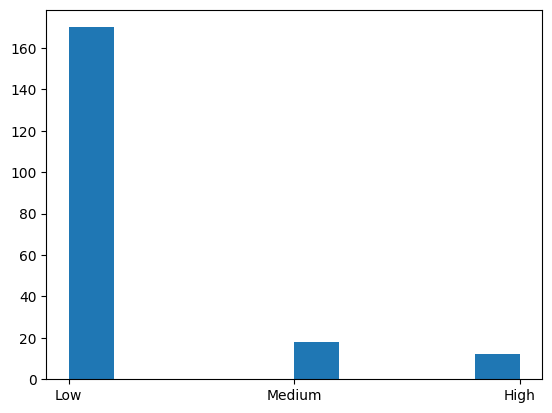

In [11]:
data['length']=data['length']/data['length'].max()
data['width']=data['width']/data['width'].max()
data['height']=data['height']/data['height'].max()

#binning grouping values
bins=np.linspace(min(data['price']),max(data['price']),4)
group_names=['Low','Medium','High']
data['price-binned']=pd.cut(data['price'],bins,labels=group_names,include_lowest=True)
print(data['price-binned'])
plt.hist(data['price-binned'])
plt.show()


**STEP 8: Convert Categorical Data to Numerical**

Machine learning models require numerical data. We convert categorical variables into numerical ones using one-hot encoding:

In [13]:
pd.get_dummies(data['fuel-type']).head()
data.describe().round(2)

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-L/100km,highway-mpg,price
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,0.83,98.85,0.84,0.92,0.90,2555.70,126.86,10.17,9.94,30.70,13205.69
std,1.25,6.04,0.06,0.03,0.04,518.59,41.65,4.01,2.54,6.83,7966.98
min,-2.00,86.60,0.68,0.84,0.80,1488.00,61.00,7.00,4.80,16.00,5118.00
25%,0.00,94.50,0.80,0.89,0.87,2163.00,97.75,8.57,7.83,25.00,7775.00
50%,1.00,97.00,0.83,0.91,0.90,2414.00,119.50,9.00,9.79,30.00,10270.00
75%,2.00,102.40,0.88,0.93,0.93,2928.25,142.00,9.40,12.37,34.00,16500.75
max,3.00,120.90,1.00,1.00,1.00,4066.00,326.00,23.00,18.08,54.00,45400.00


**Step 9: Data Visualization**

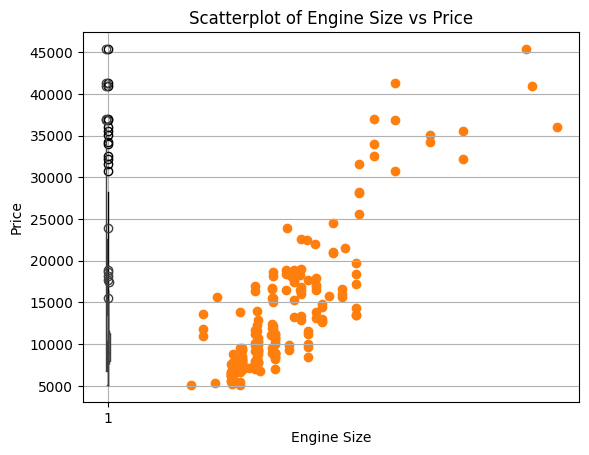

In [14]:
plt.boxplot(data['price'])
sns.boxplot(x='drive-wheels',y='price',data=data)
plt.scatter(data['engine-size'],data['price'])
plt.title('Scatterplot of Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.grid()
plt.show()


**Step 10: Grouping Data by Drive-Wheels and Body-Style**

In [18]:
test=data[['drive-wheels','body-style','price']]
data_grp=test.groupby(['drive-wheels','body-style'],as_index=False).mean()
data_grp.round(2)

,drive-wheels,body-style,price
0,4wd,hatchback,7603.00
1,4wd,sedan,12647.33
2,4wd,wagon,9095.75
3,fwd,convertible,11595.00
4,fwd,hardtop,8249.00
5,fwd,hatchback,8396.39
6,fwd,sedan,9811.80
7,fwd,wagon,9997.33
8,rwd,convertible,26563.25
9,rwd,hardtop,24202.71


**Step 11: Create a Pivot Table & Heatmap**

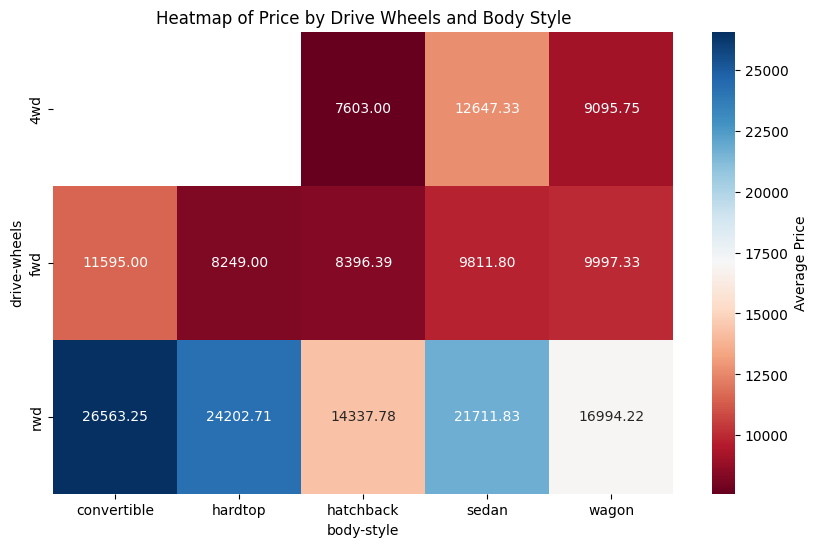

In [22]:
data_pivot = data_grp.pivot(index='drive-wheels', columns='body-style', values='price')

plt.figure(figsize=(10, 6))
sns.heatmap(data_pivot, annot=True, fmt='.2f', cmap='RdBu', cbar_kws={'label': 'Average Price'})
plt.title('Heatmap of Price by Drive Wheels and Body Style')
plt.show()

**Step 12: Perform ANOVA Test**

The Analysis of Variance (ANOVA) test helps determine if different groups have significantly different means.

F_onewayResult(statistic=np.float64(0.19744030127462608), pvalue=np.float64(0.6609478240622193))


/tmp/ipykernel_3883/3409321735.py:4: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  grouped_annova.get_group('honda')['price'],
/tmp/ipykernel_3883/3409321735.py:5: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  grouped_annova.get_group('subaru')['price']


(0.0, 53329.60168965895)

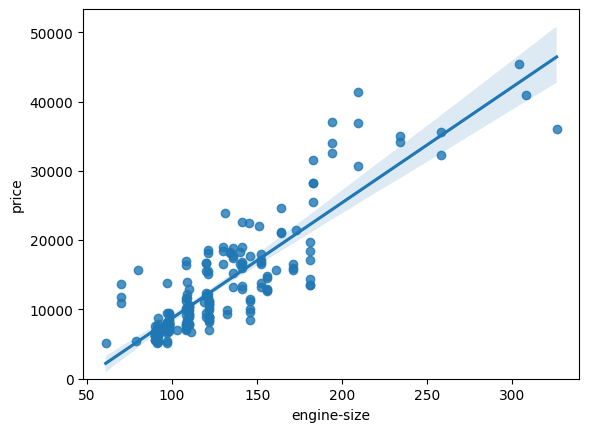

In [23]:
data_annova = data[['make', 'price']]
grouped_annova = data_annova.groupby(['make'])
annova_results_l = sp.stats.f_oneway(
                             grouped_annova.get_group('honda')['price'],
                             grouped_annova.get_group('subaru')['price']
                                    )
print(annova_results_l)

sns.regplot(x ='engine-size', y ='price', data = data)
plt.ylim(0, )

This step-by-step analysis helps in understanding the key factors influencing the selling price of used cars. Proper data cleaning, visualization and statistical tests ensure that our findings are accurate and insightful.